In [5]:
import numpy as np
import matplotlib.pyplot as plt
def science_plot(fontsize=9, scistyle=True, show_latex=True):
    # Default settings (applied to both 2D and 3D)
    if scistyle:
        import scienceplots
        plt.style.use(['science','grid','notebook'])
    if show_latex:
        plt.rcParams.update({
            # Latex Use
            'text.usetex'     : True,        # Use LaTeX for text rendering
            'font.family'     : 'serif',     # Set font family to serif
        })

    plt.rcParams.update({
        # Fontsizes
        'font.size'       : fontsize,    # General font size
        'axes.titlesize'  : fontsize,    # Font size of the axes title
        'axes.labelsize'  : fontsize,    # Font size of the axes labels
        'xtick.labelsize' : fontsize,    # Font size of the x-axis tick labels
        'ytick.labelsize' : fontsize,    # Font size of the y-axis tick labels
        'legend.fontsize' : fontsize,    # Font size of the legend
        'figure.titlesize': fontsize,    # Font size of the figure title

        # Legend
        'legend.fancybox' : False,       # Disable the fancy box for legend
        'legend.edgecolor': 'k',         # Set legend border color to black
    })
science_plot(fontsize=9)

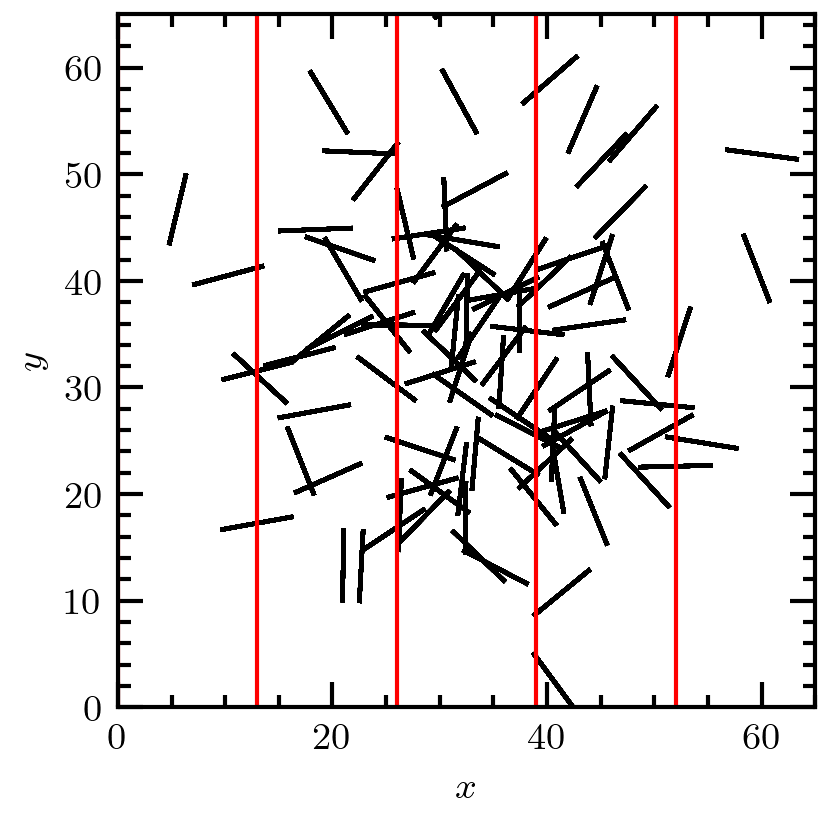

32
3.125


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
board_size = 65
toothpick_length = 6.5
line_interval = 13
n_trials = 100  # number of toothpicks

# x_start = np.random.random(0,65,n_trials)
# y_start = np.random.random(0,65,n_trials)

spread = 12
x_start = np.random.normal(board_size/2,spread,n_trials)
y_start = np.random.normal(board_size/2,spread,n_trials)

angles = np.random.uniform(0, 2*np.pi, n_trials)
x_end = x_start + toothpick_length * np.cos(angles)
y_end = y_start + toothpick_length * np.sin(angles)


plt.figure(figsize = (3,3), dpi=300)
for i in range(n_trials):
    plt.plot([x_start,x_end],[y_start,y_end],'k-',lw=1)
for i in range(5):
    plt.plot([i*13,i*13],[0,65],'r-',lw=1)
plt.xlim(0,65)
plt.ylim(0,65)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid(False)
plt.show()

# A toothpick crosses a line if floor(x_start / line_interval) != floor(x_end / line_interval)
crosses = (np.floor(x_start / line_interval) != np.floor(x_end / line_interval))
n_cross = np.sum(crosses)
print(n_cross)
# P = 2*L / (pi*d) => pi = 2*L*n / (d*n_cross)
pi_est = 2 * toothpick_length * n_trials / (line_interval * n_cross)
print(pi_est)


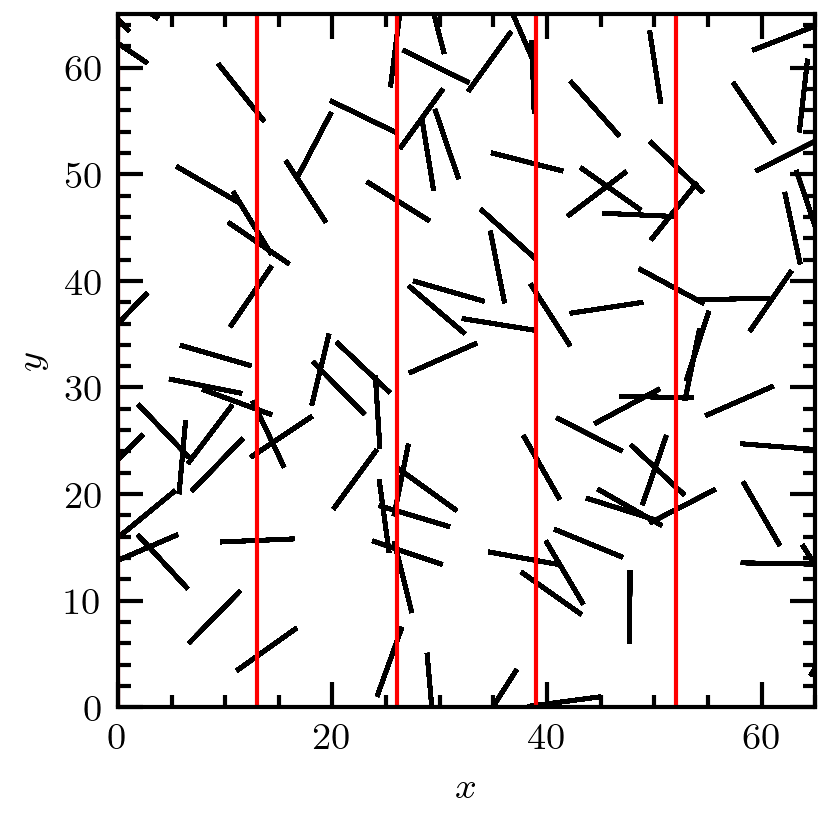

39
2.5641025641025643


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
board_size = 65
toothpick_length = 6.5
line_interval = 13
n_trials = 100  # number of toothpicks

# x_start = np.random.random(0,65,n_trials)
# y_start = np.random.random(0,65,n_trials)

spread = 12
x_start = np.random.uniform(0,65,n_trials)
y_start = np.random.uniform(0,65,n_trials)

angles = np.random.uniform(0, 2*np.pi, n_trials)
x_end = x_start + toothpick_length * np.cos(angles)
y_end = y_start + toothpick_length * np.sin(angles)


plt.figure(figsize = (3,3), dpi=300)
for i in range(n_trials):
    plt.plot([x_start,x_end],[y_start,y_end],'k-',lw=1)
for i in range(5):
    plt.plot([i*13,i*13],[0,65],'r-', lw=1)
plt.xlim(0,65)
plt.ylim(0,65)
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid(False)
plt.show()

# A toothpick crosses a line if floor(x_start / line_interval) != floor(x_end / line_interval)
crosses = (np.floor(x_start / line_interval) != np.floor(x_end / line_interval))
n_cross = np.sum(crosses)
print(n_cross)
# P = 2*L / (pi*d) => pi = 2*L*n / (d*n_cross)
pi_est = 2 * toothpick_length * n_trials / (line_interval * n_cross)
print(pi_est)


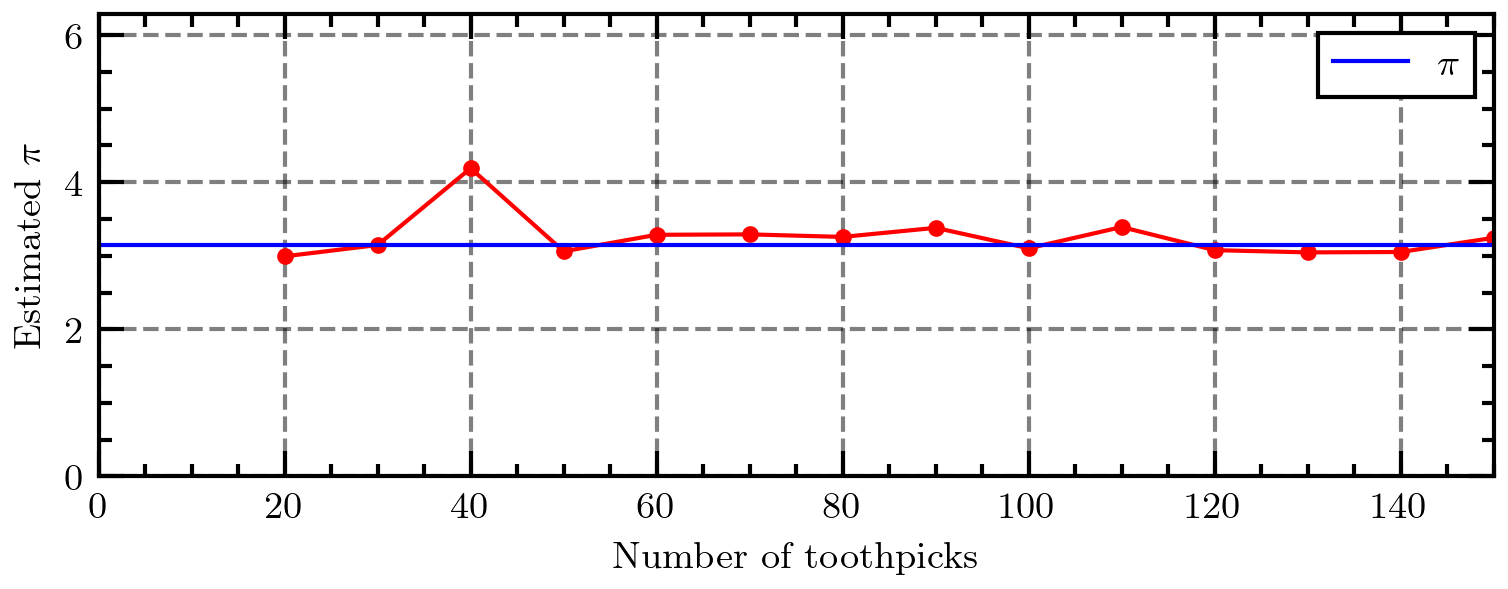

Last estimate: 3.244085088175333


In [14]:
import numpy as np
import matplotlib.pyplot as plt

board_size = 65
spread = 12  # standard deviation for normal distribution
toothpick_length = 6.5
line_interval = 13

gap = 10
nmax=150
n_throws = np.arange(0, nmax+gap, gap)  # start at 10 to avoid n=0
n_trials = 10
pp = np.zeros_like(n_throws, dtype=float)

for j in range(n_trials):
    p = np.zeros_like(n_throws, dtype=float)
    for i, n in enumerate(n_throws):
        x_start = np.random.normal(board_size/2, spread, n)
        y_start = np.random.normal(board_size/2, spread, n)
        angles = np.random.uniform(0, 2*np.pi, n)
        x_end = x_start + toothpick_length * np.cos(angles)
        y_end = y_start + toothpick_length * np.sin(angles)

        # Count crosses through vertical lines
        crosses = (np.floor(x_start / line_interval) != np.floor(x_end / line_interval))
        n_cross = np.sum(crosses)
        
        if n_cross > 0:
            pi_est = 2 * toothpick_length * n / (line_interval * n_cross)
            p[i] = pi_est
        else:
            p[i] = np.nan
    pp += p 

pp /= n_trials

plt.figure(figsize=(6,2),dpi=300)
plt.plot(n_throws, pp, 'r.-', lw = 1)
plt.axhline(np.pi, color='b', linestyle='-', label=r'$\pi$', lw =1)
plt.ylim(0, 2*np.pi)
plt.xlim(n_throws.min(),n_throws.max())
plt.xlabel("Number of toothpicks")
plt.ylabel(r"Estimated $\pi$")
#plt.text(25,6,f'Number of trials = {n_trials}',va='center')
plt.legend(fancybox=False)
plt.show()

print("Last estimate:", pp[-1])
